In [13]:
import pandas as pd
import matplotlib.pylab as plt
import pickle
import numpy as np

In [14]:
### load the data - in pickle format
file_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/open_research_section/correlation_HFdepth_EQ.pkl'
file_ = open(file_, 'rb')
data_depth = pickle.load(file_)

In [15]:
### load the data - in pickle format
file_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/open_research_section/correlation_SWD_HF.pkl'
file_ = open(file_, 'rb')
data_swd = pickle.load(file_)

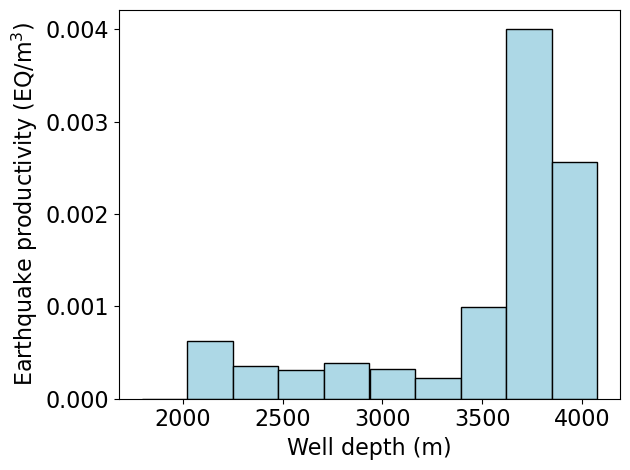

In [16]:
## plot correlation seismicity - well depth

bins = data_depth['bins_HF_depth']
productivity = data_depth['earthquake_productivity']
width = int(np.diff(bins).min())

fig,ax = plt.subplots()
ax.bar(bins,productivity,width = width,color = 'lightblue',edgecolor = 'black')
ax.set_xlabel("Well depth (m)",fontsize=16)
ax.tick_params('both',labelsize=16)
ax.set_ylabel("Earthquake productivity (EQ/m$^{3}$)",fontsize=16)
plt.tight_layout()

In [17]:
vecpp_sort = np.sort(vecpp)[::-1]
vecpp_indsort = np.argsort(vecpp)[::-1]
ratio = vec_seismicity_cluster/vec_seismicity_all
ratio_shuf = vec_seismicity_cluste_shuf/vec_seismicity_all_shuf
ratio_mean_shuf = ratio_shuf.mean(1)

ratio_shuf_sort_norm = np.nancumsum(ratio_shuf[vecpp_indsort,:],0) / np.nancumsum(ratio_shuf[vecpp_indsort,:],0)[-1,:]
ratio_mean_shuf_sort_norm = np.nancumsum(ratio_mean_shuf[vecpp_indsort]) / np.nancumsum(ratio_mean_shuf[vecpp_indsort])[-1]


borne_inf = np.zeros(ratio.shape[0])
borne_sup = np.zeros(ratio.shape[0])

for i in range(ratio.shape[0]):
    std_ = np.std(ratio_shuf_sort_norm[i,:])
    borne_inf[i] = ratio_mean_shuf_sort_norm[i] - 1.96*std_
    borne_sup[i] = ratio_mean_shuf_sort_norm[i] + 1.96*std_
    

fig,ax = plt.subplots()
p1 = ax.plot(np.linspace(0,1,ratio.shape[0]),vecpp[vecpp_indsort].cumsum() / vecpp[vecpp_indsort].cumsum()[-1],'b-',label = 'Pore-pressure (DWD)')
p2 = ax.plot(np.linspace(0,1,len(ratio)),np.nancumsum(ratio[vecpp_indsort]) / np.nancumsum(ratio[vecpp_indsort])[-1],'r-',label='Fraction of HF-related EQs')
p3 = ax.plot(np.linspace(0,1,ratio.shape[0]),ratio_mean_shuf_sort_norm,'k-',label = 'mean of 1000 random EQ distributions')
p4 = ax.fill_between(np.linspace(0,1,ratio.shape[0]),borne_inf,borne_sup,color='k',alpha = 0.2,label = '95$\%$ confidence interval')




ax.legend(frameon = False,fontsize = 11)
ax.set_xlim(0,1.01)
ax.set_ylim(0,1.01)
ax.set_xlabel('Fraction of covered area',fontsize = 16)
ax.set_ylabel('Normalized quantity',fontsize = 16)
ax.tick_params('both',labelsize = 16)
plt.tight_layout()

<>:24: SyntaxWarning: invalid escape sequence '\%'
<>:24: SyntaxWarning: invalid escape sequence '\%'
/var/folders/kj/lxqq_3f54x55m7d9pkbmm_z40000gn/T/ipykernel_51101/1140298313.py:24: SyntaxWarning: invalid escape sequence '\%'
  p4 = ax.fill_between(np.linspace(0,1,ratio.shape[0]),borne_inf,borne_sup,color='k',alpha = 0.2,label = '95$\%$ confidence interval')
/var/folders/kj/lxqq_3f54x55m7d9pkbmm_z40000gn/T/ipykernel_51101/1140298313.py:24: SyntaxWarning: invalid escape sequence '\%'
  p4 = ax.fill_between(np.linspace(0,1,ratio.shape[0]),borne_inf,borne_sup,color='k',alpha = 0.2,label = '95$\%$ confidence interval')


NameError: name 'vecpp' is not defined

In [18]:
data_swd['Shuffled'].shape

(361, 3)

<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:11: SyntaxWarning: invalid escape sequence '\%'
/var/folders/kj/lxqq_3f54x55m7d9pkbmm_z40000gn/T/ipykernel_51101/1212212708.py:11: SyntaxWarning: invalid escape sequence '\%'
  p4 = ax.fill_between(x_,y_shuf[:,1],y_shuf[:,2],color='k',alpha = 0.2,label = '95$\%$ confidence interval')


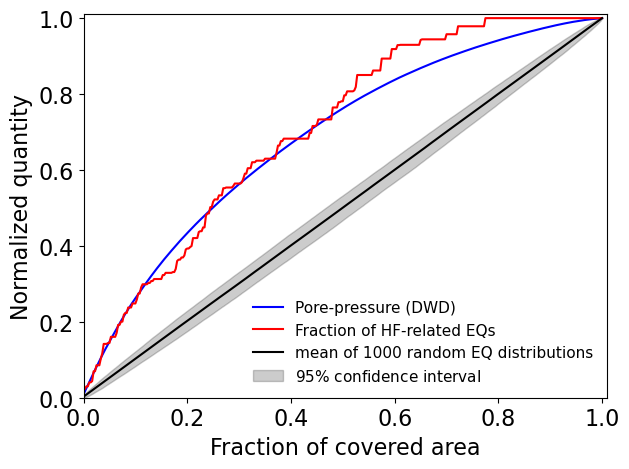

In [19]:
## plot correlation SWD-related pore-pressure - HF susceptibility
x_ = data_swd['x_']
y_hf = data_swd['HF']
y_shuf = data_swd['Shuffled']
y_swd = data_swd['Pore-pressure']

fig,ax = plt.subplots()
p1 = ax.plot(x_,y_swd,'b-',label = 'Pore-pressure (DWD)')
p2 = ax.plot(x_,y_hf,'r-',label='Fraction of HF-related EQs')
p3 = ax.plot(x_,y_shuf[:,0],'k-',label = 'mean of 1000 random EQ distributions')
p4 = ax.fill_between(x_,y_shuf[:,1],y_shuf[:,2],color='k',alpha = 0.2,label = '95$\%$ confidence interval')

ax.legend(frameon = False,fontsize = 11)
ax.set_xlim(0,1.01)
ax.set_ylim(0,1.01)
ax.set_xlabel('Fraction of covered area',fontsize = 16)
ax.set_ylabel('Normalized quantity',fontsize = 16)
ax.tick_params('both',labelsize = 16)
plt.tight_layout()


